In [1]:
import sys
sys.path.append('../../')
from notebook_utils import plot_contour, plot_dset
import pylab as plt
import torch
import torch.nn as nn
from sklearn import datasets

import lightning as L
from dal_toolbox.models.deterministic import DeterministicModel
from dal_toolbox.models.deterministic.simplenet import SimpleNet as Net
from dal_toolbox.models.utils.callbacks import MetricHistory
from dal_toolbox.metrics import Accuracy

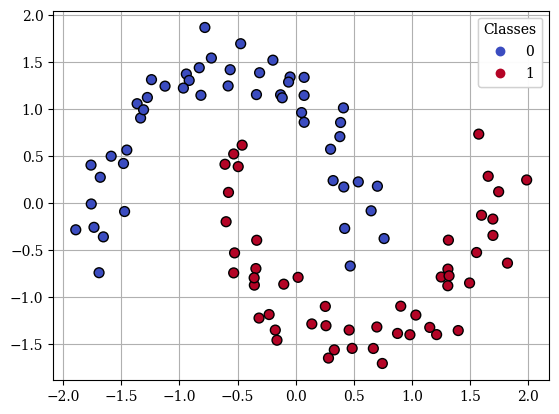

In [2]:
X, y = datasets.make_moons(100, noise=.1, random_state=42)
# X, y = datasets.make_circles(500, noise=.02)
X = (X - X.mean(0)) / X.std(0)
X = torch.from_numpy(X).float()
y = torch.from_numpy(y).long()

train_ds = torch.utils.data.TensorDataset(X, y)

plot_dset(X_l=X, y_l=y)
plt.show()

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name          | Type             | Params
---------------------------------------------------
0 | model         | SimpleNet        | 17.2 K
1 | loss_fn       | CrossEntropyLoss | 0     
2 | train_metrics | ModuleDict       | 0     
3 | val_metrics   | ModuleDict       | 0     
---------------------------------------------------
17.2 K    Trainable params
0         Non-trainable params
17.2 K    Total params
0.069     Total estimated model params size (MB)


Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=200` reached.


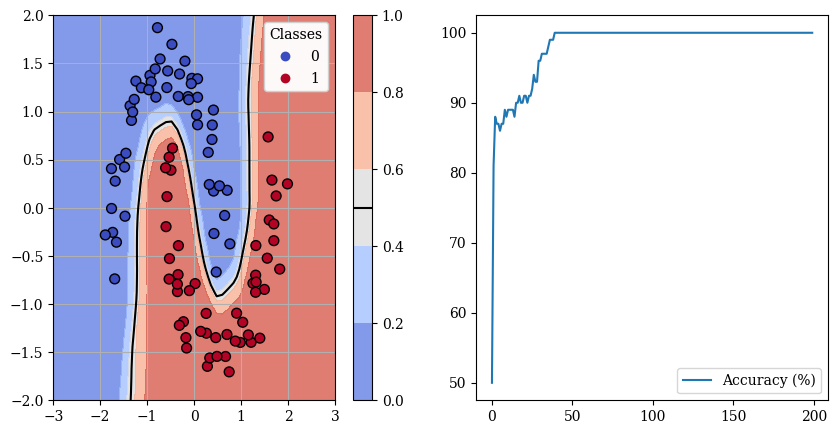

In [3]:
num_epochs = 200
torch.manual_seed(0)
train_loader = torch.utils.data.DataLoader(train_ds, batch_size=128, shuffle=True)

model = Net(num_classes=2)
optimizer = torch.optim.SGD(model.parameters(), lr=1e-1, momentum=0.9)
model = DeterministicModel(model, loss_fn=nn.CrossEntropyLoss(label_smoothing=0.05), optimizer=optimizer, train_metrics={'accuracy': Accuracy()} )

history = MetricHistory()
trainer = L.Trainer(max_epochs=num_epochs, callbacks=[history])
trainer.fit(model, train_loader)

model.eval()
plt.figure(figsize=(10, 5))
plot_contour(model, X_l=X, y_l=y, ax=plt.subplot(121), x_domain=(-3, 3), y_domain=(-2, 2))
plt.subplot(122)
plt.plot([h['accuracy']*100 for h in history], label='Accuracy (%)')
plt.legend()
plt.show()